# 02 — Feature Engineering: Elo ratings

**Goal:** turn 150 years of results into a single *strength* number per team (Elo),
validate it makes football sense, and visualize how power shifts across decades.

Elo is the backbone feature for the classifier. Implementation lives in
[`src/features/elo.py`](../src/features/elo.py).

> **Quant link:** the Elo update `R += K*(S - E)` is an *exponentially weighted* (EWMA)
> estimator — each result decays geometrically in influence, exactly like a RiskMetrics
> EWMA of returns. `K` is the smoothing parameter (bigger K = faster reaction, shorter memory).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))  # make 'src' importable

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.features.elo import compute_elo  # noqa: E402
print("Imported Elo engine from src/features/elo.py")

Imported Elo engine from src/features/elo.py


In [2]:
# Run Elo over the FULL history (warm-up), as decided in the EDA.
matches = pd.read_csv(ROOT / "data" / "processed" / "matches_clean.csv", parse_dates=["date"])
elo = compute_elo(matches)

print(f"Matches processed: {len(elo.match_features):,}")
print(f"Teams rated: {len(elo.final_ratings):,}")
elo.match_features.tail(3)

Matches processed: 49,405
Teams rated: 334


,date,home_team,away_team,home_elo_pre,away_elo_pre,elo_diff
49402,2026-06-10,England,Costa Rica,2094.959877,1755.381338,339.578540
49403,2026-06-10,Portugal,Nigeria,2061.247397,1888.517433,172.729964
49404,2026-06-10,Afghanistan,Pakistan,1203.651123,1092.406652,111.244471


## 1. Sanity check: do the top ratings make football sense?

A model is only as trustworthy as its inputs. If the strongest teams by Elo were minnows,
we'd have a bug. We expect the usual powerhouses at the top.

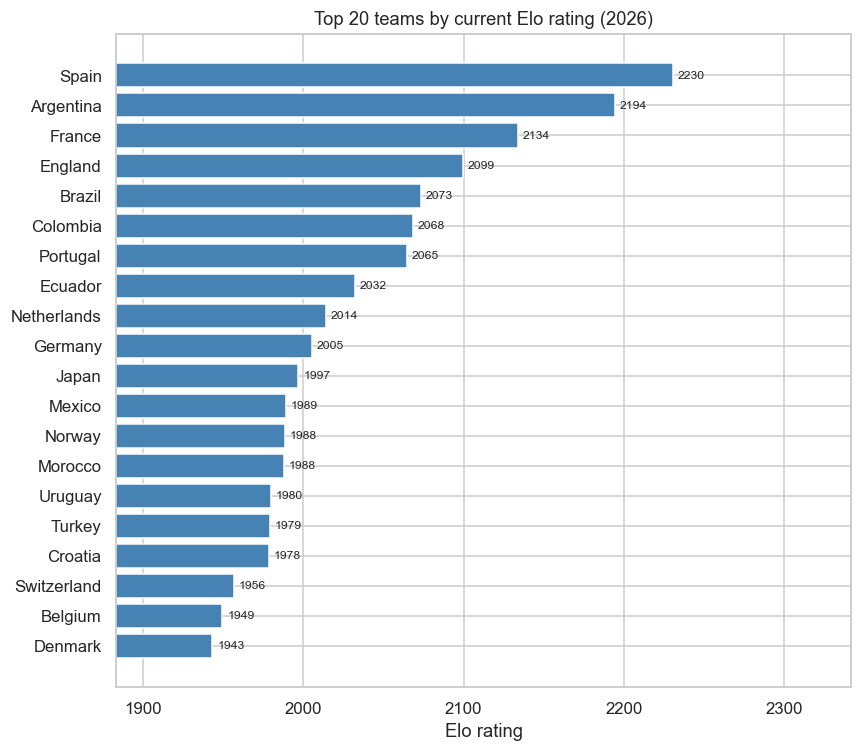

In [3]:
top20 = pd.Series(elo.final_ratings).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="steelblue")
ax.set(title="Top 20 teams by current Elo rating (2026)", xlabel="Elo rating")
ax.set_xlim(left=top20.min() - 60)
for i, v in enumerate(top20.values[::-1]):
    ax.text(v + 3, i, f"{v:.0f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_top20_elo.png", bbox_inches="tight")
plt.show()

## 2. How does football power shift over time?

Because Elo has memory, we can watch dynasties rise and fall. We plot a yearly-averaged
Elo for a handful of historic powers.

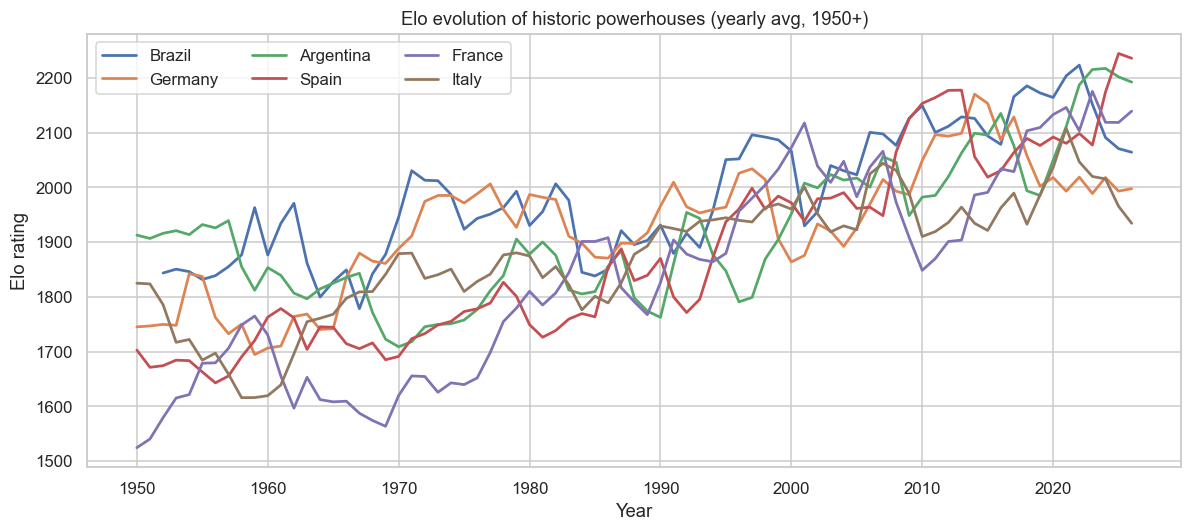

In [4]:
teams = ["Brazil", "Germany", "Argentina", "Spain", "France", "Italy"]
hist = elo.history[elo.history["team"].isin(teams)].copy()
hist["year"] = hist["date"].dt.year
# Yearly average rating per team (smooths match-to-match noise).
yearly = hist[hist["year"] >= 1950].groupby(["year", "team"])["rating"].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 5))
for team in teams:
    ax.plot(yearly.index, yearly[team], label=team, lw=1.8)
ax.set(title="Elo evolution of historic powerhouses (yearly avg, 1950+)",
       xlabel="Year", ylabel="Elo rating")
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_elo_evolution.png", bbox_inches="tight")
plt.show()

## Reading the chart & next steps

The peaks line up with real history — e.g. **Spain** surging around 2008–2012 (Euro–World
Cup–Euro treble), **France** climbing into 2018–2022, **Brazil**'s long high plateau. That
the curves match known dynasties is strong evidence the rating is sound.

**What Elo gives the model:** a single, leakage-safe, pre-match strength number whose
*difference* (`elo_diff`) is the most powerful single predictor of a match outcome.

➡️ **Next:** `src/features/build_features.py` — assemble the match-level training table
(`elo_diff`, recent form, rest days, neutral flag, target H/D/A), filtered to 2002+.